In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

Head of Data:
                                 Open        High         Low       Close  \
Date                                                                        
2025-11-26 00:00:00-05:00  320.570841  324.778087  316.993189  320.071167   
2025-11-28 00:00:00-05:00  323.219125  326.666888  316.733366  319.911285   
2025-12-01 00:00:00-05:00  317.267996  319.421589  313.775279  314.914520   
2025-12-02 00:00:00-05:00  316.693365  318.392269  314.015120  315.813934   
2025-12-03 00:00:00-05:00  315.823946  321.830037  314.075087  320.410950   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-11-26 00:00:00-05:00  29839600        0.0           0.0  
2025-11-28 00:00:00-05:00  19695800        0.0           0.0  
2025-12-01 00:00:00-05:00  28520600        0.0           0.0  
2025-12-02 00:00:00-05:00  24668200        0.0           0.0  
2025-12-03 00:00:00-05:00  32285100        0.0           0.0  


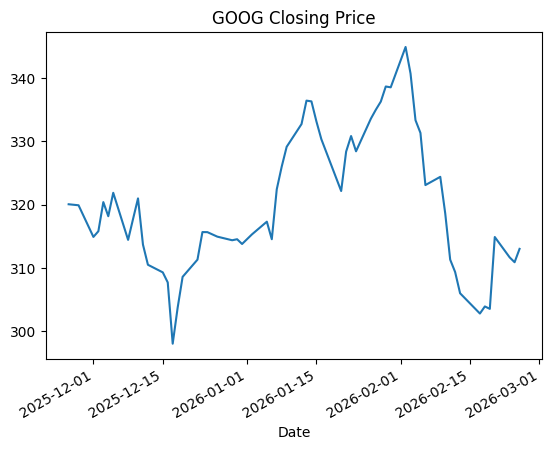

In [ ]:
# Pull stock data
ticker_symbol = "GOOG" # Ticker symbol = Google
ticker_data = yf.Ticker(ticker_symbol)

# Set data period to 3 months
ticker_df = ticker_data.history(period='3mo')
print("Head of Data:")
print(ticker_df.head())
ticker_df['Close'].plot(title='GOOG Closing Price')
plt.show()

In [ ]:
# Clean pulled data

# Reset index and simplify the timezone index
ticker_df.index = pd.to_datetime(ticker_df.index).tz_localize(None)

# Drop unnecessary columns
ticker_df = ticker_df.drop(columns=['Dividends', 'Stock Splits'])

# Check for and drop missing values
print("Missing values:\n", ticker_df.isnull().sum())
ticker_df = ticker_df.dropna()

print(ticker_df.head())

Missing values:
 Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
                  Open        High         Low       Close    Volume
Date                                                                
2025-11-26  320.570841  324.778087  316.993189  320.071167  29839600
2025-11-28  323.219125  326.666888  316.733366  319.911285  19695800
2025-12-01  317.267996  319.421589  313.775279  314.914520  28520600
2025-12-02  316.693365  318.392269  314.015120  315.813934  24668200
2025-12-03  315.823946  321.830037  314.075087  320.410950  32285100


In [ ]:
# Calculate SMA & EMA

# Simple Moving Average (20-day and 50-day)
ticker_df['SMA_20'] = ticker_df['Close'].rolling(window=20).mean()
ticker_df['SMA_50'] = ticker_df['Close'].rolling(window=50).mean()

# Exponential Moving Average (20-day)
ticker_df['EMA_20'] = ticker_df['Close'].ewm(span=20, adjust=False).mean()

print(ticker_df[['Close', 'SMA_20', 'SMA_50', 'EMA_20']].tail(10))

                 Close      SMA_20      SMA_50      EMA_20
Date                                                      
2026-02-11  311.329987  330.970499  322.196236  327.687000
2026-02-12  309.369995  329.623499  322.085345  325.942523
2026-02-13  306.019989  328.266498  321.889467  324.045139
2026-02-17  302.820007  326.890498  321.537648  322.023698
2026-02-18  303.940002  325.979498  321.252799  320.301441
2026-02-19  303.559998  324.738498  320.886400  318.707018
2026-02-20  314.899994  323.941498  320.895399  318.344444
2026-02-23  311.690002  323.104498  320.774199  317.710688
2026-02-24  310.920013  321.970999  320.572599  317.063957
2026-02-25  313.029999  320.872499  320.559199  316.679771


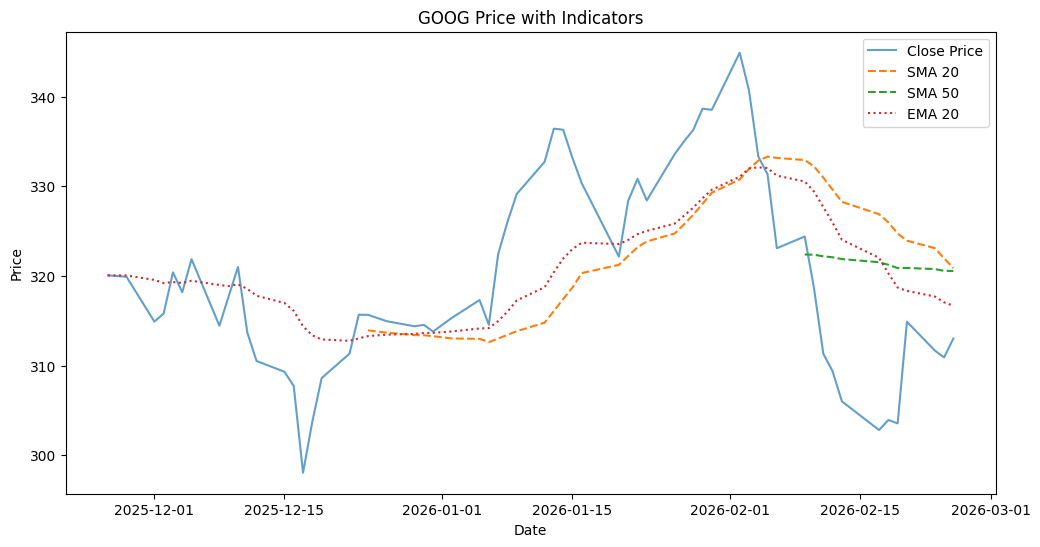

In [6]:
# Visualize indicators

plt.figure(figsize=(12, 6))
plt.plot(ticker_df['Close'], label='Close Price', alpha=0.7)
plt.plot(ticker_df['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(ticker_df['SMA_50'], label='SMA 50', linestyle='--')
plt.plot(ticker_df['EMA_20'], label='EMA 20', linestyle=':')
plt.title('GOOG Price with Indicators')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [7]:
# Generate Signals

# Buy signal: when SMA_20 crosses above SMA_50
# Sell signal: when SMA_20 crosses below SMA_50
ticker_df['Signal'] = 0
ticker_df.loc[ticker_df['SMA_20'] > ticker_df['SMA_50'], 'Signal'] = 1   # Buy
ticker_df.loc[ticker_df['SMA_20'] < ticker_df['SMA_50'], 'Signal'] = -1  # Sell

# Show where signals change (actual crossover points)
ticker_df['Signal_Change'] = ticker_df['Signal'].diff()
print(ticker_df[ticker_df['Signal_Change'] != 0][['Close', 'SMA_20', 'SMA_50', 'Signal']])

                 Close      SMA_20      SMA_50  Signal
Date                                                  
2025-11-26  320.071167         NaN         NaN       0
2026-02-09  324.399994  332.930499  322.396685       1


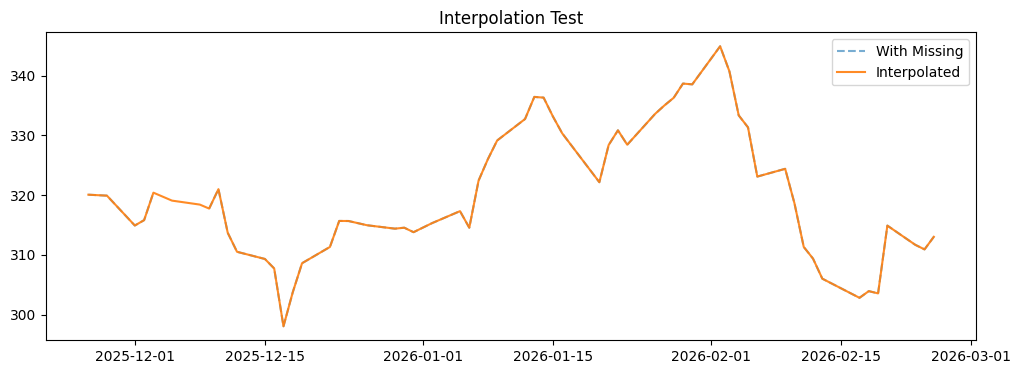

In [ ]:
# Test Interpolation

# Introduce some missing values to test interpolation
ticker_df_test = ticker_df['Close'].copy()
ticker_df_test.iloc[5:8] = np.nan  # blank out a few rows

# Fill using linear interpolation
ticker_df_test_filled = ticker_df_test.interpolate(method='linear')

# Plot original vs interpolated
plt.figure(figsize=(12, 4))
plt.plot(ticker_df_test, label='With Missing', linestyle='--', alpha=0.6)
plt.plot(ticker_df_test_filled, label='Interpolated', alpha=0.9)
plt.title('Interpolation Test')
plt.legend()
plt.show()